# This notebook is an overview of some concepts and properties of probability distributions and their application to data via python

### More specifically, it is about shifting and fitting different probability distributions to data. Representation of data in histograms is also adressed.

In [1]:
import numpy as np
import scipy as sc
import lmfit as lm
import scipy.special as sp
from scipy.stats import rv_discrete
import matplotlib.pyplot as plt

### 1. Histograms, PDF and CDF

In [2]:
rng = np.random.default_rng(100)
draws = rng.geometric(p=1/4, size=1000000)
weighted = np.ones(len(draws))/len(draws)

Text(0.5, 1.0, 'probability density')

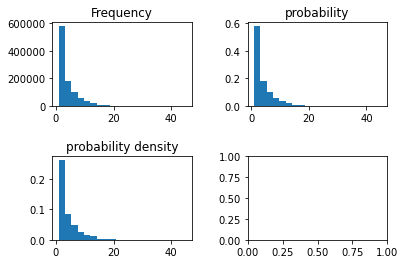

In [3]:
fig, ax = plt.subplots(2, 2)
fig.subplots_adjust(hspace=0.6, wspace=0.4)

ax[0, 0].hist(x=draws, bins=20)
ax[0, 0].set_title("Frequency")

ax[0, 1].hist(x=draws, bins=20, weights=weighted)
ax[0, 1].set_title("probability")

ax[1, 0].hist(x=draws, bins=20, density=True)
ax[1, 0].set_title("probability density")

Matplotlib histogram of values will first have the absolute **frequency** of each bin on the y-axis.\
One can **weight** the values such that each value contributes its associated weight (e.g. normalized to the total number of values) to the bin count instead of 1 (note: dividing the bin count by the total count does the same). This yields the **relative frequency distribution** or **probability**, all values add up to a total of 1.\
One can convert it to a **probability density** by either saying **density=True** or dividing the weighted values by the **bin width**. This leads to a histogram whose integral is 1, i.e. whose totals of $x*y$ yields 1.\
\
The probability densities can be overlayed by a PDF (probability density function). The y-values of a PDF is not the probability! The probability at any x-value is 0, since there are infinite possible x-values. To yield the probability *in a certain interval*, one needs the CDF (cumulative distribution function), which is the integral of the PDF. A PDF can reach y-values above 1, if the distributions corresponding x-interval is small. Vice versa, if the bin width is large, the PDF y-values can become very small.\
One can convert a PDF to a PMF-like function (probability mass function) by multiplying it with the bin width. The bin width can be estimated with the total x-range divided by the bin count. 

### 2. Geometric distribution and shifting a function

The geometric distribution is a discrete (i.e. not continuous) distribution with a PMF of $P(k=(1,2,3, ...))=(1-p)^{k-1}*p$. As one can see, k does not take the value of 0. To still being able to draw 0's from a geometric distribution, one has to shift the distribution.\
\
To shift a function to the left, one has to **add** the value to the x component of the function. Vice versa, to shift it to the right, one has to **subtract** the value from the x component.\
\
In the case of the geometric distribution, when shifting it by 1 to the left, it becomes $P(k=(0,1,2,...))=(1-p)^k*p$. Alternatively, one can **subtract** 1 from each of the resulting draws, e.g. when drawing the samples with rng.geometric(). In the case scipy.geom, the loc value is subtracted from k, therefore one has to apply a loc of -1 to end up adding it to k (the x component).\
\
The mean is shifted the same way as every other x-value. In the case of the geometric distribution, if the p-value is not adjusted, the mean will shift according to the applied shifting. $p=\frac{1}{µ}$ - to keep the mean µ constant,  one can adjust p by $p=\frac{1}{µ+1}$, in case the PMF is shifted by 1 to the left.\
\
A shifted PDF cannot be "expanded" in left x-direction: the density functions integral (CDF) has to be equal to 1 in the shifted interval. 

### 3. Gamma and exponential distribution

Every exponential distribution is also a gamma distribution with the gamma distributions property of $\alpha = 1$. One can therefore fix the parameter of e.g. scipy.gamma.fit to 1 to yield an exponential distribution. The gamma distribution of scipy is $f(x, a)=\frac{x^{\alpha-1}e^{-x}}{\Gamma(\alpha)}$. If the scale parameter ≠ 1 then $scale = \frac{1}{\beta}$ with $f(x, a, \beta)=\frac{\beta^{\alpha}x^{\alpha-1}e^{-\beta*x}}{\Gamma(\alpha)}$. To shift the distribution in x-direction, the loc parameter can be used: a positive loc shifts it in right direction, because x becomes x-loc. Note, that the mean is $\mu = \frac{a}{\beta} + loc = scale*a+loc$.

### 4. Truncated distributions

A truncated distribution is a probability distribution which is not complete. It misses information below and/or above (a) certain x-value(s), i.e. the lower bound a and the upper bound b. The PDF of such a truncated distribution is given by the non-truncated distribution $f(x)$ times an indicator function $I(a < x \le b)$, which is then divided by $F(b) - F(a)$, where F is the CDF of the non-truncated distribution f(x). Therefore, $pdf_{truncated}=\frac{f(x)*I}{F(b)-F(a)}$. 

In [4]:
samples_gamma = sc.stats.gamma.rvs(a=1.1, loc=0, scale=11000, size=10000000)

truncation_point = 5999
samples_gamma_trunc = samples_gamma[samples_gamma > truncation_point]

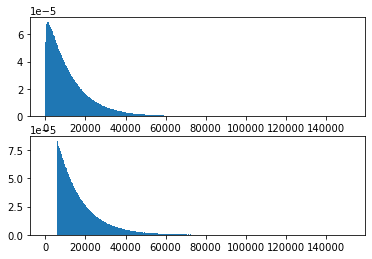

In [5]:
fig, ax = plt.subplots(2)
bins = np.arange(0, 152000+100, 100)

non_trunc_hist = ax[0].hist(x=samples_gamma, bins=bins, density=True)

trunc_hist = ax[1].hist(x=samples_gamma_trunc, bins=bins, density=True)

#### How to fit this data? 

In the plots above, the probability densities were plotted. This means, both plots integrate to 1 and can be overlayed with an according PDF. In the first scenario, the standard gamma distributions PDF will be perfect. In the second scenario, the truncated gamma distribution would be desired. Since this simply resembles curve fitting, one can extract the y and x data points of the plots (if the probability densities were not calculated manually) and fit them with the according functions.\
\
Note that the smaller the binwidth, the more accurate the fitting process becomes. A smaller bin width might result in single bins being equal to zero. They have to be integrated, since the non-zero bins are compensatingly larger (it still has to integrate to 1).\
\
Note that the probability densities estimated to generate the histogram (or, similarily, if generated manually), display mean values of certain $x_0, x_1$ ranges where $x_1 = x_0 + bin width$. Therefore, when taking the first y-value and the first x-values (which resembles $x_0$), the true y-value would be larger, if the y-values decrease with increasing x or smaller, if y-values increase with increasing x. 

In [6]:
# extract y and x data points of the histogram; note that x data points are 1 too many since
# it contains the starting and ending values the bins - the last ending value is no starting value,
# so it should be excluded.
non_trunc_ydata = non_trunc_hist[0]
non_trunc_xdata = non_trunc_hist[1][:-1]

# note: the truncated data points should be filtered for the interval above the lower boundary a and, if given
# below the upper boundary b. This accounts for the indicator function I, which can then be skipped.
trunc_ydata = trunc_hist[0]
trunc_xdata = trunc_hist[1][:-1]

first_data_point_index = np.argmax(trunc_ydata>0)
trunc_ydata = trunc_ydata[first_data_point_index:]
trunc_xdata = trunc_xdata[first_data_point_index:]

In [7]:
def pdf_gamma(x, alpha, beta):
    return beta**alpha / sc.special.gamma(alpha) * x**(alpha-1)*np.exp(-beta*x)
# Note: in this pdf_gamma representation, beta is equal to 1/scale of scipy.stats.gamma


# the CDF of the gamma distribution is the regularized lower incomplete gamma function
def cdf_gamma(x, alpha, beta):
    return sc.special.gammainc(alpha, beta*x)


# see Wikipedia truncated distribution; the indicator function can be neglected, since the x values are truncated,
# aswell.
def pdf_truncated_gamma(x, alpha, beta, lower_bound, upper_bound=None):
    if upper_bound is None:
        return pdf_gamma(x, alpha, beta)/(1 - cdf_gamma(lower_bound, alpha, beta))
    else:
        return pdf_gamma(x, alpha, beta)/(cdf_gamma(upper_bound, alpha, beta) - cdf_gamma(lower_bound, alpha, beta))

In [8]:
model = lm.Model(pdf_truncated_gamma, independent_vars=["x"])
params = lm.Parameters()
params.add("alpha", value=3, min=0.01, max=10)
params.add("beta", value=1/11000, min=1/20000, max=1/1000)
params.add("lower_bound", vary=False, value=6000)
result = model.fit(trunc_ydata, x=trunc_xdata, params=params)
trunc_alpha = result.params["alpha"].value
trunc_beta = result.params["beta"].value
print(trunc_alpha, trunc_beta)

1.2788861887365661 9.914038551732485e-05


Note: for the non-truncated distribution, the standard MLE Fit with gamma.fit is better because the leastsq fitting to the x-value of 0 is very sensitive for starting parameters. E.g. with an alpha value of $\ge 1.4$ as an initial value when the true value 1.1, lmfit is not working anymore. 

In [9]:
model = lm.Model(pdf_gamma, independent_vars=["x"])
params_ = lm.Parameters()
params.add("alpha", value=1.2, min=0.01, max=10)
params.add("beta", value=1/11000, min=1/20000, max=1/1000)
result = model.fit(non_trunc_ydata, x=non_trunc_xdata, params=params)
non_trunc_alpha = result.params["alpha"].value
non_trunc_beta = result.params["beta"].value
print(non_trunc_alpha, non_trunc_beta)

1.0943496534195762 9.012535840833782e-05


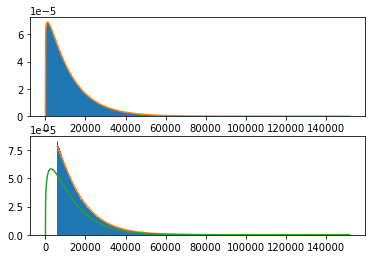

In [10]:
fig, ax = plt.subplots(2)
bins = np.arange(0, 152000+100, 100)

ax[0].hist(x=samples_gamma, bins=bins, density=True)
ax[0].plot(non_trunc_xdata, pdf_gamma(non_trunc_xdata, non_trunc_alpha, non_trunc_beta))

ax[1].hist(x=samples_gamma_trunc, bins=bins, density=True)
ax[1].plot(trunc_xdata, pdf_truncated_gamma(trunc_xdata, trunc_alpha, trunc_beta, lower_bound=6000))
ax[1].plot(non_trunc_xdata, pdf_gamma(non_trunc_xdata, trunc_alpha, trunc_beta))

### The moments of probability theory

The skewness (third moment in scipy.stats) describes how (a-)symmetric a distribution is. 

## Using scipy's rv_discrete subclass method to generate additional distributions

### Truncated geometric distribution

In [29]:
def pmf_geometric(x, p):

    return (1 - p)**x * p


def cdf_geometric(x, p):

    return 1 - (1 - p)**(x+1)


def pmf_truncated_geometric(x, p, upper_bound, lower_bound):
    
    return pmf_geometric(x, p) / (cdf_geometric(upper_bound, p) - cdf_geometric(lower_bound, p))

In [30]:
lower_bound = 2
upper_bound = 10
x = np.arange(lower_bound+1, upper_bound+1, 1)  # the interval of truncation is a half-open interval (a, b], 
# meaning that truncated pdf or pmf is true for values above a and below or equal to b. Therefore, when setting
# a lower bound of a truncated pmf, the lowest valid value of x in pmf_truncated(x) is lower_bound + 1.
p = 0.5

probabilities = pmf_truncated_geometric(x, p, upper_bound, lower_bound)
print(np.sum(probabilities))

1.0


In contrast to the PDF, a PMF(x) yields the probability of x. The probabilities of all possible x (the support) should sum to 1.

In [31]:
trunc_geo = rv_discrete(name="trunc_geo", values=(x, probabilities))
sample = trunc_geo.rvs(size=1000)
mean = trunc_geo.moment(1)
print(mean)
print(np.mean(sample))

3.9686274509803923
3.967


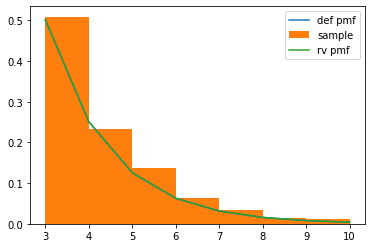

In [34]:
fig, ax = plt.subplots()
ax.plot(x, pmf_truncated_geometric(x, p, upper_bound, lower_bound), label="def pmf")
ax.hist(sample, density=True, bins=x, label="sample")
ax.plot(x, trunc_geo.pmf(x), label="rv pmf")
ax.legend()

## Shifted geometric distribution

In [35]:
def shifted_pmf_geometric(x, p, shift):

    return (1 - p)**(x-shift) * p


def shifted_cdf_geometric(x, p, shift):

    return 1 - (1 - p)**(x+1-shift)

Caution: the function defined above needs the previous support to be shifted by shift aswell. E.g., the geometric distribution f(x) (ignoring the added shift) supports $x \in \{0, 1, 2, ...\}$. If the distribution is shifted by 2, the support is $x \in \{2, 3, 4, ...\}$. 

In [55]:
rng = np.random.default_rng(100)
shift = 10
x_shift = np.arange(10, 10000, 1)
p = 0.5
probabilities = shifted_pmf_geometric(x_shift, p, shift)
print(np.sum(probabilities))
shifted = rv_discrete(name="shifted", values=(x_shift, probabilities))
sample_shifted = shifted.rvs(size=1000, random_state=rng)
print(shifted.moment(1))
print(np.mean(sample_shifted))

1.0
11.0
11.045


In [57]:
shifted_cdf_geometric(10, p, shift)

0.5

In [37]:
rng = np.random.default_rng(100)
shift = 0
x = np.arange(0, 10000, 1)
p = 0.5
probabilities = shifted_pmf_geometric(x, p, shift)
print(np.sum(probabilities))
not_shifted = rv_discrete(name="shifted", values=(x, probabilities))
sample_not_shifted = not_shifted.rvs(size=1000, random_state=rng)
print(not_shifted.moment(1))
print(np.mean(sample_not_shifted))

1.0
1.0
1.045


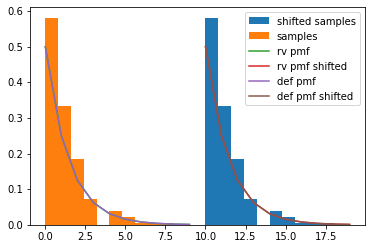

In [43]:
fig, ax = plt.subplots()
# samples
ax.hist(sample_shifted, density=True, label="shifted samples")
ax.hist(sample_not_shifted, density=True, label="samples")
# rv pmf
ax.plot(x[:10], not_shifted.pmf(x[:10]), label="rv pmf")
ax.plot(x_shift[:10], shifted.pmf(x_shift[:10]), label="rv pmf shifted")
# def pmf
ax.plot(x[:10], shifted_pmf_geometric(x[:10], p, 0), label="def pmf")
ax.plot(x_shift[:10], shifted_pmf_geometric(x_shift[:10], p, 10), label="def pmf shifted")
ax.legend()

## Combining shifting with truncation

As an example, the poisson distribution is taken, since it is not memoryless (in contrast to the geometric distribution).

First, shift the distribution.

In [15]:
def shifted_pmf_poisson(x, rate, shift):
    
    return (np.power(rate, (x-shift), dtype=float)*np.exp(-rate))/sp.factorial((x-shift))
    # note that np.power with dtype=float has to be used, since the int32 overflows
    # dtpye = int64 might also work
    
    
def shifted_cdf_poisson(x, rate, shift):
    floor = np.floor(x+1-shift)
    
    return sp.gammaincc(floor, rate)

In [16]:
rng = np.random.default_rng(100)
shift = 10
x_shift = np.arange(0+shift, 100+shift, 1)
rate = 10
probabilities = shifted_pmf_poisson(x_shift, rate, shift)
shifted = rv_discrete(name="shifted", values=(x_shift, probabilities))
sample_shifted = shifted.rvs(size=1000, random_state=rng)
print(np.sum(probabilities))

1.0


In [4]:
rng = np.random.default_rng(100)
shift = 0
x = np.arange(0+shift, 100+shift, 1)
rate = 10
probabilities = shifted_pmf_poisson(x, rate, shift)
non_shifted = rv_discrete(name="non_shifted", values=(x, probabilities))
sample_non_shifted = non_shifted.rvs(size=1000, random_state=rng)
print(np.sum(probabilities))

1.0


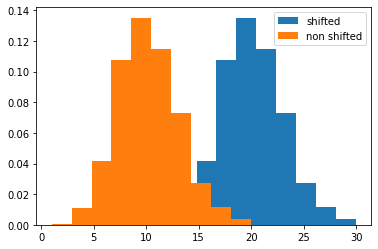

In [5]:
fig, ax = plt.subplots()
ax.hist(sample_shifted, density=True, label="shifted")
ax.hist(sample_non_shifted, density=True, label="non shifted")
ax.legend()

Second, truncate the distribution.

In [19]:
def pmf_poisson(x, rate):
    
    return (np.power(rate, x, dtype=float)*np.exp(-rate))/sp.factorial((x))


def cdf_poisson(x, rate):
    floor = np.floor(x+1)
    return sp.gammaincc(floor, rate)


def truncated_pmf_poisson(x, rate, upper_bound, lower_bound):
    return pmf_poisson(x, rate) / (cdf_poisson(upper_bound, rate) - 
                                   cdf_poisson(lower_bound, rate))

In [7]:
rng = np.random.default_rng(100)
rate = 10
upper_bound = 100
lower_bound = 0
x = np.arange(lower_bound+1, upper_bound+1, 1)  # half open interval
probabilities = truncated_pmf_poisson(x, rate, upper_bound, lower_bound)
non_trunc = rv_discrete(name="non_trunc", values=(x, probabilities))
sample_non_trunc = non_trunc.rvs(size=1000, random_state=rng)
print(np.sum(probabilities))

1.0


In [8]:
rng = np.random.default_rng(100)
rate = 10
upper_bound = 100
lower_bound = 6
x = np.arange(lower_bound+1, upper_bound+1, 1)
probabilities = truncated_pmf_poisson(x, rate, upper_bound, lower_bound)
trunc = rv_discrete(name="trunc", values=(x, probabilities))
sample_trunc = trunc.rvs(size=1000, random_state=rng)
print(np.sum(probabilities))

1.0


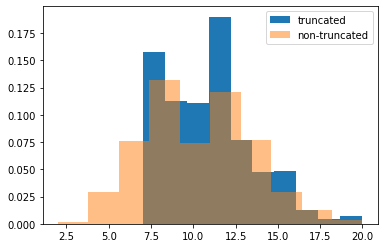

In [9]:
fig, ax = plt.subplots()
ax.hist(sample_trunc, density=True, label="truncated")
ax.hist(sample_non_trunc, density=True, alpha=0.5, label="non-truncated")
ax.legend()

Then, combine it

In [10]:
def shifted_pmf_poisson(x, rate, shift):
    
    return (np.power(rate, (x-shift), dtype=float)*np.exp(-rate))/sp.factorial((x-shift))


def cdf_poisson(x, rate):
    floor = np.floor(x+1)
    
    return sp.gammaincc(floor, rate)


def truncated_shifted_pmf_poisson(x, rate, upper_bound, lower_bound, shift):
    
    # do not use the shifted cdf, because the probabilities given by shifted_pmf_poisson
    # are equal to the probabilities of the original support given no shift.
    # The truncation is then carried out given the non-shifted distribution.
    return shifted_pmf_poisson(x, rate, shift) / (cdf_poisson(upper_bound, rate) -
                                                  cdf_poisson(lower_bound, rate))

In [11]:
rng = np.random.default_rng(100)
shift = 0
rate = 10
upper_bound = 100
lower_bound = 10
x = np.arange(lower_bound+1+shift, upper_bound+1+shift, 1)
probabilities = truncated_shifted_pmf_poisson(x, rate, upper_bound, lower_bound, shift)
non_shift = rv_discrete(name="non_shift", values=(x, probabilities))
sample_non_shift = non_shift.rvs(size=1000, random_state=rng)
print(np.sum(probabilities))

0.9999999999999991


In [12]:
rng = np.random.default_rng(100)
shift = 5
rate = 10
upper_bound = 100
lower_bound = 10
x = np.arange(lower_bound+1+shift, upper_bound+1+shift, 1)  
# important: always add the shift to the support
probabilities = truncated_shifted_pmf_poisson(x, rate, upper_bound, lower_bound, shift)
shift = rv_discrete(name="shift", values=(x, probabilities))
sample_shift = shift.rvs(size=1000, random_state=rng)
print(np.sum(probabilities))

0.9999999999999991


In [13]:
rng = np.random.default_rng(100)
shift = 5
x_shift = np.arange(0+shift, 100, 1)
rate = 10
probabilities = shifted_pmf_poisson(x_shift, rate, shift)
shifted = rv_discrete(name="shifted", values=(x_shift, probabilities))
sample_shifted = shifted.rvs(size=1000, random_state=rng)
print(np.sum(probabilities))

1.0


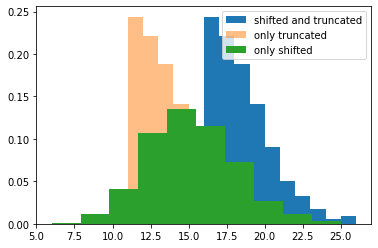

In [14]:
fig, ax = plt.subplots()
ax.hist(sample_shift, density=True, label="shifted and truncated")
ax.hist(sample_non_shift, density=True, alpha=0.5, label="only truncated")
ax.hist(sample_shifted, density=True, label="only shifted")
ax.legend()

### Back to the geometric distribution

Since the geometric distribution is memoryless, there is no difference between shifting or truncating the distribution

In [332]:
def pmf_geometric(x, p):

    return (1 - p)**x * p


def cdf_geometric(x, p):

    return 1 - (1 - p)**(x+1)


def pmf_truncated_geometric(x, p, upper_bound, lower_bound):
    
    return pmf_geometric(x, p) / (cdf_geometric(upper_bound, p) - cdf_geometric(lower_bound, p))


def shifted_pmf_geometric(x, p, shift):

    return (1 - p)**(x-shift) * p


def shifted_cdf_geometric(x, p, shift):

    return 1 - (1 - p)**(x+1-shift)


def shifted_truncated_pmf_geometric(x, p, upper_bound, lower_bound, shift):
    
    return shifted_pmf_geometric(x, p, shift) / (cdf_geometric(upper_bound, p) -
                                                 cdf_geometric(lower_bound, p))

In [333]:
def mean_trunc_geo(p, lower_bound, upper_bound, shift):
    x = np.arange(lower_bound+1+shift, upper_bound+1+shift, 1) 
    
    return np.sum(x * shifted_pmf_geometric(x, p, shift)) / (cdf_geometric(upper_bound, p) - 
                                                             cdf_geometric(lower_bound, p))

Note for future use: it may be beneficial to define the support (e.g., for a truncated shifted distribution x = np.arange(lower_bound + 1 + shift, upper_bound + 1 + shift, 1) within the function (of the PMF), just like it was done in mean_trunc_geo.

In [294]:
rng = np.random.default_rng(100)
shift = 0
p = 0.5
upper_bound = 100
lower_bound = 10
x = np.arange(lower_bound+1+shift, upper_bound+1+shift, 1)
probabilities = shifted_truncated_pmf_geometric(x, p, upper_bound, lower_bound, shift)
non_shift = rv_discrete(name="non_shift", values=(x, probabilities))
sample_non_shift = non_shift.rvs(size=1000, random_state=rng)
print(np.sum(probabilities))

1.0


In [295]:
rng = np.random.default_rng(100)
shift = 5
p = 0.5
upper_bound = 100
lower_bound = 10
x = np.arange(lower_bound+1+shift, upper_bound+1+shift, 1)  
# important: always add the shift to the support
probabilities = shifted_truncated_pmf_geometric(x, p, upper_bound, lower_bound, shift)
shift = rv_discrete(name="shift", values=(x, probabilities))
sample_shift = shift.rvs(size=1000, random_state=rng)
print(np.sum(probabilities))

1.0


In [296]:
print(shift.moment(1))
print(np.mean(sample_shift))
print(mean_trunc_geo(p, lower_bound, upper_bound, 5))

17.0
17.045
17.0


In [297]:
rng = np.random.default_rng(100)
shift = 5
x_shift = np.arange(0+shift, 100, 1)
p = 0.5
probabilities = shifted_pmf_geometric(x_shift, p, shift)
shifted = rv_discrete(name="shifted", values=(x_shift, probabilities))
sample_shifted = shifted.rvs(size=1000, random_state=rng)
print(np.sum(probabilities))

1.0


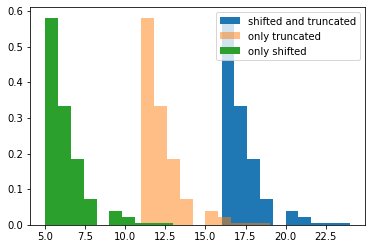

In [331]:
fig, ax = plt.subplots()
ax.hist(sample_shift, density=True, label="shifted and truncated")
ax.hist(sample_non_shift, density=True, alpha=0.5, label="only truncated")
ax.hist(sample_shifted, density=True, label="only shifted")
ax.legend()

Mistake in convex hull truncated_geometric_distribution.py: 

def pmf_truncated_geometric(x, p, upper_bound, lower_bound, shift):
    return shifted_pmf_geometric(x, p, shift) / (shifted_cdf_geometric(upper_bound, p, shift) -
                                                 shifted_cdf_geometric(lower_bound, p, shift))

with x = np.arange(lower_bound+1, upper_bound+1, 1) (see def truncated_geometric)

There are two mistakes: shift is not added to the x values,
and
the shifted cdf is taken instead of the non-shifted cdf. 

In this form, shift is not doing anything: shifted_pmf_geometric returns completely different values
depending on shift, since it was not added to x. This effect is completely reversed by shifted_cdf_geometric. \
Note, that these mistakes do not influence anything of the results of convex hull, since only truncation was needed.

Also, mean_trunc_geo is wrong (correct version above), this was not used anywhere.